# Data Type Inference Agent

A LangGraph-based agent that:
1. Loads data from up to 3 CSV or PKL files (processed sequentially)
2. Infers data types for each column with reasoning
3. Asks the user for feedback on each column (one at a time)
4. Uses an LLM to interpret natural language responses
5. Applies transformations based on user feedback

This agent uses LangGraph's `interrupt()` for human-in-the-loop interaction, `MemorySaver` for state persistence, and Amazon Bedrock for LLM inference.

## Setup and Imports

In [1]:
import operator
import os
import pickle
import re
from datetime import datetime
from io import StringIO
from pathlib import Path
from typing import Annotated, Any, Literal, TypedDict

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from pydantic import BaseModel, Field

print("✅ All imports successful!")

✅ All imports successful!


## Configuration

Define the file paths to analyze (up to 3 files). Files will be processed sequentially.

In [2]:
# ============================================================
# CONFIGURATION - Set your file paths here (up to 3 files)
# ============================================================
FILE_PATHS = [
    "../Airbnb/Barcelona/listings.csv",
    # "../Airbnb/Athens/listings.csv",
    # "../Airbnb/Berlin/listings.csv",
]

# Validate configuration
if len(FILE_PATHS) > 3:
    print(f"⚠️ Warning: Maximum 3 files allowed. Only first 3 will be processed.")
    FILE_PATHS = FILE_PATHS[:3]

print(f"📁 Files to process: {len(FILE_PATHS)}")
for i, fp in enumerate(FILE_PATHS):
    if Path(fp).exists():
        print(f"   {i+1}. ✅ {fp}")
    else:
        print(f"   {i+1}. ❌ {fp} (NOT FOUND)")

📁 Files to process: 1
   1. ✅ ../Airbnb/Barcelona/listings.csv


## LLM Setup (Amazon Bedrock)

Configure the LLM for interpreting user responses.

In [3]:
import boto3
from botocore.config import Config
from botocore import UNSIGNED
from langchain_aws import ChatBedrockConverse

load_dotenv()

token = os.environ.get("AWS_BEARER_TOKEN_BEDROCK")

if not token:
    print("⚠️ AWS_BEARER_TOKEN_BEDROCK not found in environment.")
    print("   Make sure you have a .env file with the token.")
else:
    print("✅ AWS Bearer Token loaded")

bedrock_client = boto3.client(
    "bedrock-runtime",
    region_name="us-east-1",
    config=Config(signature_version=UNSIGNED),
)

def add_bearer_token(request, **kwargs):
    request.headers["Authorization"] = f"Bearer {token}"

bedrock_client.meta.events.register("before-send.bedrock-runtime.*", add_bearer_token)

llm = ChatBedrockConverse(
    model="us.anthropic.claude-sonnet-4-20250514-v1:0",
    client=bedrock_client,
)

print("✅ LLM configured (Claude Sonnet via Amazon Bedrock)")

✅ AWS Bearer Token loaded
✅ LLM configured (Claude Sonnet via Amazon Bedrock)


## Agent State Schema

The state holds all information the agent needs throughout its execution.

In [ ]:
class ColumnInfo(TypedDict):
    """Information about a single column's type inference."""
    column_name: str
    inferred_type: str
    reasoning: str
    sample_values: list[str]
    confidence: float
    user_approved: bool | None  # None = not yet reviewed
    user_correction: str | None  # User's requested type if they disagree
    transformation_applied: bool


class FileState(TypedDict):
    """State for a single file being processed."""
    file_path: str
    original_df: pd.DataFrame | None  # Original DataFrame (unchanged)
    working_df: pd.DataFrame | None   # DataFrame being transformed
    column_names: list[str]
    current_column_index: int
    column_info: dict[str, ColumnInfo]
    status: str  # 'pending', 'loading', 'inferring', 'transforming', 'cleaning', 'complete'


class DataAnalysisState(TypedDict):
    """Complete state for the multi-file data analysis agent."""
    # Multi-file tracking
    files_to_process: list[str]  # Up to 3 file paths
    current_file_index: int  # Which file we're processing (0, 1, or 2)
    file_states: dict[str, FileState]  # file_path -> FileState
    apply_decisions_to_all_files: bool  # Whether to apply decisions from first file to all remaining files
    
    # Stored decisions from first file (for reuse when apply_decisions_to_all_files is True)
    stored_column_decisions: dict[str, dict]  # column_name -> {'type': str, 'approved': bool, 'correction': str|None}
    stored_duplicate_decision: bool | None  # True = drop duplicates, False = keep, None = not decided yet
    stored_nil_decisions: dict[str, str]  # column_name -> action ('fill_median', 'fill_zero', etc.)
    stored_columns_to_drop: list[str]  # List of column names to drop
    
    # Processing log (appends across all files)
    processing_log: Annotated[list[str], operator.add]
    
    # Overall status (includes data cleaning phases)
    status: str  # 'loading', 'inferring', 'awaiting_feedback', 'transforming', 
                 # 'checking_duplicates', 'checking_nil_values', 'showing_statistics', 'complete'
    
    # Data cleaning tracking (temporary, reset per file)
    _nil_columns_processed: list[str]  # Tracks which nil columns have been handled


print("✅ State schema defined!")
print("\n📋 Key state fields:")
print("   • files_to_process — List of up to 3 file paths")
print("   • current_file_index — Which file is being processed")
print("   • file_states — Per-file state (data, columns, progress)")
print("   • apply_decisions_to_all_files — Reuse decisions for remaining files")
print("   • stored_*_decisions — Saved decisions for reuse across files")
print("   • processing_log — Combined log across all files")
print("   • status — Current phase including data cleaning stages")

✅ State schema defined!

📋 Key state fields:
   • files_to_process — List of up to 3 file paths
   • current_file_index — Which file is being processed
   • file_states — Per-file state (data, columns, progress)
   • processing_log — Combined log across all files
   • status — Current phase including data cleaning stages


## Helper Functions

Utility functions for data loading and type inference.

In [5]:
def load_file_as_dataframe(file_path: str) -> pd.DataFrame:
    """
    Load a file (CSV or PKL) as a DataFrame.
    All columns are read as strings to avoid automatic type inference.
    """
    path = Path(file_path)
    
    if not path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")
    
    suffix = path.suffix.lower()
    
    if suffix == '.csv':
        # Read CSV with all columns as strings
        df = pd.read_csv(
            file_path,
            dtype=str,
            keep_default_na=False
        )
    elif suffix in ['.pkl', '.pickle']:
        # Load pickle file
        with open(file_path, 'rb') as f:
            df = pickle.load(f)
        
        # Convert to DataFrame if not already
        if not isinstance(df, pd.DataFrame):
            raise ValueError(f"Pickle file does not contain a DataFrame: {type(df)}")
        
        # Convert all columns to string to avoid assumptions
        df = df.astype(str)
    else:
        raise ValueError(f"Unsupported file format: {suffix}. Supported: .csv, .pkl, .pickle")
    
    return df


def dataframe_to_csv_string(df: pd.DataFrame) -> str:
    """Convert DataFrame to CSV string for storage in state."""
    return df.to_csv(index=False)


def csv_string_to_dataframe(csv_string: str) -> pd.DataFrame:
    """Reconstruct DataFrame from CSV string."""
    return pd.read_csv(StringIO(csv_string), dtype=str, keep_default_na=False)


print("✅ Helper functions defined!")

✅ Helper functions defined!


## Type Inference Logic

Functions to infer data types with reasoning for each column.

In [6]:
def detect_datetime_format(series: pd.Series) -> dict[str, Any]:
    """Detect if a series contains datetime values."""
    formats = [
        ('%Y-%m-%d', '2024-01-15'),
        ('%Y/%m/%d', '2024/01/15'),
        ('%d-%m-%Y', '15-01-2024'),
        ('%d/%m/%Y', '15/01/2024'),
        ('%m-%d-%Y', '01-15-2024'),
        ('%m/%d/%Y', '01/15/2024'),
        ('%Y-%m-%d %H:%M:%S', '2024-01-15 14:30:00'),
        ('%Y-%m-%dT%H:%M:%S', '2024-01-15T14:30:00'),
        ('%Y-%m-%dT%H:%M:%SZ', '2024-01-15T14:30:00Z'),
        ('%b %d, %Y', 'Jan 15, 2024'),
        ('%B %d, %Y', 'January 15, 2024'),
    ]
    
    sample = series.dropna().head(100)
    if len(sample) == 0:
        return {'is_datetime': False, 'format': None, 'confidence': 0}
    
    best_format = None
    best_example = None
    best_success_rate = 0
    
    for fmt, example in formats:
        success_count = 0
        for val in sample:
            try:
                datetime.strptime(str(val), fmt)
                success_count += 1
            except:
                pass
        
        success_rate = success_count / len(sample)
        if success_rate > best_success_rate:
            best_success_rate = success_rate
            best_format = fmt
            best_example = example
    
    return {
        'is_datetime': best_success_rate > 0.8,
        'format': best_format,
        'format_example': best_example,
        'confidence': best_success_rate
    }


print("✅ Datetime detection defined!")

✅ Datetime detection defined!


In [ ]:
def infer_column_type(series: pd.Series, column_name: str) -> ColumnInfo:
    """
    Infer the data type of a column with detailed reasoning.
    Only returns these 7 basic pandas-compatible types: text, boolean, identifier, integer, float, datetime, categorical
    """
    non_empty = series[series != '']
    total_count = len(series)
    non_empty_count = len(non_empty)
    empty_count = total_count - non_empty_count
    unique_count = series.nunique()
    unique_ratio = unique_count / total_count if total_count > 0 else 0
    sample_values = non_empty.head(5).tolist() if len(non_empty) > 0 else []
    
    # Handle empty column - treat as text
    if non_empty_count == 0:
        return ColumnInfo(
            column_name=column_name,
            inferred_type='text',
            reasoning=f'All {total_count} values are empty or missing. Defaulting to text.',
            sample_values=[],
            confidence=1.0,
            user_approved=None,
            user_correction=None,
            transformation_applied=False
        )
    
    # 1. Check for identifier
    col_lower = column_name.lower()
    if unique_ratio > 0.95 and any(x in col_lower for x in ['id', '_id', 'identifier', 'key']):
        return ColumnInfo(
            column_name=column_name,
            inferred_type='identifier',
            reasoning=f'Column name suggests ID, high uniqueness: {unique_ratio:.1%}.',
            sample_values=sample_values,
            confidence=0.9,
            user_approved=None,
            user_correction=None,
            transformation_applied=False
        )
        
    # 2. Check for boolean
    unique_lower = set(non_empty.str.lower().str.strip().unique())
    boolean_sets = [{'t', 'f'}, {'true', 'false'}, {'yes', 'no'}, {'y', 'n'}, {'0', '1'}]
    for bool_set in boolean_sets:
        if unique_lower.issubset(bool_set) and len(unique_lower) <= 2:
            return ColumnInfo(
                column_name=column_name,
                inferred_type='boolean',
                reasoning=f'Contains only boolean-like values: {unique_lower}.',
                sample_values=sample_values,
                confidence=0.95,
                user_approved=None,
                user_correction=None,
                transformation_applied=False
            )
    
    # 3. Check for integer
    try:
        numeric_converted = pd.to_numeric(non_empty, errors='coerce')
        numeric_success_rate = numeric_converted.notna().sum() / len(non_empty)
        if numeric_success_rate > 0.9:
            valid_numeric = numeric_converted.dropna()
            is_integer = (valid_numeric == valid_numeric.astype(int)).all()
            if is_integer:
                return ColumnInfo(
                    column_name=column_name,
                    inferred_type='integer',
                    reasoning=f'{numeric_success_rate:.1%} are valid integers. Range: {int(valid_numeric.min())} to {int(valid_numeric.max())}.',
                    sample_values=sample_values,
                    confidence=float(numeric_success_rate),
                    user_approved=None,
                    user_correction=None,
                    transformation_applied=False
                )
    except:
        pass
    
    # 4. Check for float
    try:
        numeric_converted = pd.to_numeric(non_empty, errors='coerce')
        success_rate = numeric_converted.notna().sum() / len(non_empty)
        if success_rate > 0.9:
            valid_numeric = numeric_converted.dropna()
            return ColumnInfo(
                column_name=column_name,
                inferred_type='float',
                reasoning=f'{success_rate:.1%} are valid floats. Range: {valid_numeric.min():.4f} to {valid_numeric.max():.4f}.',
                sample_values=sample_values,
                confidence=float(success_rate),
                user_approved=None,
                user_correction=None,
                transformation_applied=False
            )
    except:
        pass
    
    # 5. Check for datetime
    datetime_result = detect_datetime_format(non_empty)
    if datetime_result['is_datetime']:
        return ColumnInfo(
            column_name=column_name,
            inferred_type='datetime',
            reasoning=f'Detected datetime format: {datetime_result["format"]} (e.g., {datetime_result["format_example"]}).',
            sample_values=sample_values,
            confidence=float(datetime_result['confidence']),
            user_approved=None,
            user_correction=None,
            transformation_applied=False
        )
    
    # 6. Check for categorical
    if unique_ratio < 0.05 and unique_count <= 100:
        top_cats = list(non_empty.value_counts().head(3).index)
        return ColumnInfo(
            column_name=column_name,
            inferred_type='categorical',
            reasoning=f'Low cardinality: {unique_count} unique values ({unique_ratio:.1%}). Examples: {top_cats}.',
            sample_values=sample_values,
            confidence=0.85,
            user_approved=None,
            user_correction=None,
            transformation_applied=False
        )
    
    # 7. Default to text
    avg_length = non_empty.str.len().mean()
    return ColumnInfo(
        column_name=column_name,
        inferred_type='text',
        reasoning=f'No specific pattern. {unique_count} unique values, avg length: {avg_length:.1f} chars.',
        sample_values=sample_values,
        confidence=0.8,
        user_approved=None,
        user_correction=None,
        transformation_applied=False
    )


print("✅ Type inference functions defined!")
print("\n📋 Detectable types: text, boolean, identifier, integer, float, datetime, categorical")

✅ Type inference functions defined!

📋 Detectable types: text, boolean, identifier, integer, float, datetime, categorical


## LLM Response Interpreter

Uses the LLM to interpret natural language user responses instead of simple string matching.

In [8]:
# Define structured output schema for the LLM response
class UserResponseInterpretation(BaseModel):
    """Structured interpretation of user's response about a column."""
    action: Literal["approve", "correct", "skip", "show_more_samples"] = Field(
        description="The action the user wants to take. "
                    "'approve' = accept the inferred type, "
                    "'correct' = change to a different type, "
                    "'skip' = leave column unchanged, "
                    "'show_more_samples' = user wants to see more sample values"
    )
    target_type: str | None = Field(
        default=None,
        description="If action is 'correct', the type the user wants. "
                    "Valid types: integer, float, boolean, datetime, categorical, text, identifier"
    )
    reasoning: str = Field(
        description="Brief explanation of how you interpreted the user's response"
    )


# Create structured LLM for response interpretation
structured_llm = llm.with_structured_output(UserResponseInterpretation)


def interpret_user_response(
    user_input: str,
    column_name: str,
    inferred_type: str,
    sample_values: list[str]
) -> UserResponseInterpretation:
    """
    Use the LLM to interpret what the user wants to do with this column.
    
    Args:
        user_input: The raw text response from the user
        column_name: Name of the column being discussed
        inferred_type: The type we inferred for this column
        sample_values: Sample values from the column
    
    Returns:
        Structured interpretation of the user's intent
    """
    prompt = f"""You are helping interpret a user's response about a data column type inference.

Context:
- Column name: {column_name}
- Our inferred type: {inferred_type}
- Sample values: {sample_values[:5]}

The user was asked if they agree with the inferred type '{inferred_type}' for column '{column_name}'.

User's response: "{user_input}"

Interpret what the user wants:
- If they agree/approve/confirm, action is 'approve'
- If they want a different type (e.g., "make it a date", "this should be categorical"), action is 'correct' and extract the target_type
- If they want to skip/ignore/leave as-is without converting, action is 'skip'
- If they want to see more data/samples/examples, action is 'show_more_samples'

Valid target types for 'correct' action: integer, float, boolean, datetime, categorical, text, identifier
"""
    
    result = structured_llm.invoke(prompt)
    return result


print("✅ LLM Response Interpreter defined!")
print("\n📋 Supported actions:")
print("   • approve — Accept the inferred type")
print("   • correct — Change to a different type")
print("   • skip — Leave column unchanged")
print("   • show_more_samples — Display more sample values")

✅ LLM Response Interpreter defined!

📋 Supported actions:
   • approve — Accept the inferred type
   • correct — Change to a different type
   • skip — Leave column unchanged
   • show_more_samples — Display more sample values


## LLM Type Inference

Uses the LLM to provide additional type inference based on column name, sample values, and rule-based analysis.

In [9]:
# Define structured output schema for LLM type inference
class LLMTypeInference(BaseModel):
    """LLM's analysis of a column's data type."""
    suggested_type: Literal["integer", "float", "boolean", "datetime", "categorical", "text", "identifier"] = Field(
        description="The data type the LLM suggests for this column. "
                    "Valid types: integer, float, boolean, datetime, categorical, text, identifier"
    )
    confidence: float = Field(
        description="Confidence level between 0.0 and 1.0 for this type suggestion",
        ge=0.0,
        le=1.0
    )
    reasoning: str = Field(
        description="Brief explanation of why this type was chosen based on column name and sample values"
    )


# Create structured LLM for type inference
type_inference_llm = llm.with_structured_output(LLMTypeInference)


def get_llm_type_inference(
    column_name: str,
    sample_values: list[str],
    rule_based_type: str,
    rule_based_reasoning: str,
    rule_based_confidence: float
) -> LLMTypeInference:
    """
    Use the LLM to infer the data type of a column based on its name and sample values.
    The LLM is also provided with the rule-based inference for context.
    
    Args:
        column_name: Name of the column
        sample_values: Sample values from the column
        rule_based_type: The type inferred by rule-based logic
        rule_based_reasoning: Reasoning from rule-based inference
        rule_based_confidence: Confidence from rule-based inference
    
    Returns:
        LLM's structured type inference
    """
    prompt = f"""You are a data type inference expert. Analyze the following column and determine its most appropriate data type.

Column Information:
- Column name: {column_name}
- Sample values: {sample_values[:10]}

Rule-based Analysis (for context):
- Inferred type: {rule_based_type}
- Reasoning: {rule_based_reasoning}
- Confidence: {rule_based_confidence:.1%}

Your task:
1. Consider the column name - does it suggest a specific data type? (e.g., "price" suggests float, "date" suggests datetime)
2. Examine the sample values - what patterns do you see?
3. Consider the rule-based analysis - does it make sense given the column name and values?
4. Provide your own inference with confidence level and reasoning

Valid data types (ONLY these 7 types):
- integer: Whole numbers
- float: Decimal numbers (including monetary values)
- boolean: True/False values
- datetime: Date or datetime values
- categorical: Limited set of categories
- text: Free-form text
- identifier: Unique identifiers (IDs, keys)

Be thoughtful about semantic meaning from the column name. For example:
- "price", "cost", "amount" suggest float
- "date", "time", "created_at" suggest datetime
- "id", "key", "uuid" suggest identifier
- "status", "category", "type" suggest categorical
"""
    
    result = type_inference_llm.invoke(prompt)
    return result


print("✅ LLM Type Inference defined!")
print("\n📋 The LLM will analyze:")
print("   • Column name semantics")
print("   • Sample values patterns")
print("   • Rule-based inference results")
print("   • Provide enhanced type suggestions")

✅ LLM Type Inference defined!

📋 The LLM will analyze:
   • Column name semantics
   • Sample values patterns
   • Rule-based inference results
   • Provide enhanced type suggestions


## LLM Schemas for Data Cleaning

Pydantic models for LLM-based interpretation of user decisions about duplicates, nil values, and column dropping.

In [10]:
# Schema for interpreting user response about dropping duplicates
class DuplicateDecision(BaseModel):
    """Structured interpretation of user's response about duplicate rows."""
    drop_duplicates: bool = Field(
        description="Whether the user wants to drop duplicate rows. True = drop, False = keep."
    )
    reasoning: str = Field(
        description="Brief explanation of how you interpreted the user's response"
    )


# Schema for interpreting user response about nil values
class NilValueDecision(BaseModel):
    """Structured interpretation of user's response about handling nil/missing values."""
    action: Literal["fill_median", "fill_zero", "fill_unknown", "fill_most_common", "drop_rows", "leave_empty"] = Field(
        description="The action the user wants to take for handling nil values. "
                    "'fill_median' = fill with median (numeric), "
                    "'fill_zero' = fill with 0 (numeric), "
                    "'fill_unknown' = fill with 'Unknown' (text), "
                    "'fill_most_common' = fill with most common value (text), "
                    "'drop_rows' = drop rows with missing values, "
                    "'leave_empty' = leave as-is"
    )
    reasoning: str = Field(
        description="Brief explanation of how you interpreted the user's response"
    )


# Schema for interpreting user response about dropping columns
class ColumnDropDecision(BaseModel):
    """Structured interpretation of user's response about dropping columns."""
    columns_to_drop: list[str] = Field(
        default=[],
        description="List of column names the user wants to drop. Empty list if no columns should be dropped."
    )
    reasoning: str = Field(
        description="Brief explanation of how you interpreted the user's response"
    )


# Create structured LLMs for data cleaning decisions
duplicate_decision_llm = llm.with_structured_output(DuplicateDecision)
nil_value_decision_llm = llm.with_structured_output(NilValueDecision)
column_drop_decision_llm = llm.with_structured_output(ColumnDropDecision)


def interpret_duplicate_decision(user_input: str, duplicate_count: int) -> DuplicateDecision:
    """
    Use LLM to interpret if user wants to drop duplicate rows.
    """
    prompt = f"""You are helping interpret a user's response about handling duplicate rows in a dataset.

Context:
- The dataset has {duplicate_count} duplicate rows.
- The user was asked if they want to drop these duplicates.

User's response: "{user_input}"

Interpret what the user wants:
- If they agree/approve/yes/drop/remove, they want to drop duplicates
- If they decline/no/keep/skip, they want to keep duplicates
"""
    return duplicate_decision_llm.invoke(prompt)


def interpret_nil_value_decision(user_input: str, column_name: str, is_numeric: bool, nil_count: int) -> NilValueDecision:
    """
    Use LLM to interpret how user wants to handle nil values in a column.
    """
    if is_numeric:
        options = "'fill_median', 'fill_zero', 'drop_rows', 'leave_empty'"
    else:
        options = "'fill_unknown', 'fill_most_common', 'drop_rows', 'leave_empty'"
    
    prompt = f"""You are helping interpret a user's response about handling missing/nil values in a column.

Context:
- Column name: {column_name}
- Column type: {'numeric' if is_numeric else 'text/categorical'}
- Number of missing values: {nil_count}
- Available options: {options}

User's response: "{user_input}"

Interpret what the user wants:
- 'fill_median' = fill with median value (numeric columns)
- 'fill_zero' = fill with 0 (numeric columns)
- 'fill_unknown' = fill with 'Unknown' string (text columns)
- 'fill_most_common' = fill with most common/frequent value (text columns)
- 'drop_rows' = drop all rows with missing values in this column
- 'leave_empty' = don't change anything, keep nil values
"""
    return nil_value_decision_llm.invoke(prompt)


def interpret_column_drop_decision(user_input: str, available_columns: list[str]) -> ColumnDropDecision:
    """
    Use LLM to interpret which columns user wants to drop.
    """
    prompt = f"""You are helping interpret a user's response about dropping columns from a dataset.

Context:
- Available columns: {available_columns}
- The user was shown column statistics and asked which columns they want to drop.

User's response: "{user_input}"

Interpret what the user wants:
- Extract the column names they want to drop
- If they say 'none', 'no', 'skip', or similar, return an empty list
- Match column names flexibly (partial matches, case-insensitive)
- Only include columns that exist in the available_columns list
"""
    return column_drop_decision_llm.invoke(prompt)


print("✅ Data Cleaning LLM Schemas defined!")
print("\n📋 Supported decisions:")
print("   • DuplicateDecision — Drop or keep duplicate rows")
print("   • NilValueDecision — Handle missing values")
print("   • ColumnDropDecision — Select columns to drop")

✅ Data Cleaning LLM Schemas defined!

📋 Supported decisions:
   • DuplicateDecision — Drop or keep duplicate rows
   • NilValueDecision — Handle missing values
   • ColumnDropDecision — Select columns to drop


In [ ]:
# Schema for interpreting user response about applying decisions to all files
class ApplyToAllDecision(BaseModel):
    """Structured interpretation of user's response about applying decisions to all remaining files."""
    apply_to_all: bool = Field(
        description="Whether the user wants to apply the same decisions to all remaining files. True = yes, False = no."
    )
    reasoning: str = Field(
        description="Brief explanation of how you interpreted the user's response"
    )


# Create structured LLM for apply-to-all decision
apply_to_all_decision_llm = llm.with_structured_output(ApplyToAllDecision)


def interpret_apply_to_all_decision(user_input: str, remaining_files_count: int) -> ApplyToAllDecision:
    """
    Use LLM to interpret if user wants to apply the same decisions to all remaining files.
    """
    prompt = f"""You are helping interpret a user's response about applying data cleaning decisions to multiple files.

Context:
- The first file has been processed with various data cleaning decisions (type conversions, duplicate handling, nil value handling, column drops).
- There are {remaining_files_count} more file(s) to process.
- The user was asked if they want to apply the same decisions to all remaining files.

User's response: "{user_input}"

Interpret what the user wants:
- If they agree/yes/apply/same/reuse/all, they want to apply the same decisions to all files
- If they decline/no/different/manually/each/individual, they want to make decisions for each file separately
"""
    return apply_to_all_decision_llm.invoke(prompt)


print("✅ Apply-to-All Decision Schema defined!")
print("\n📋 This allows users to apply decisions from the first file to all remaining files.")

## Column Transformation Functions

Functions to apply user-requested transformations to columns.

In [11]:
def apply_column_transformation(df: pd.DataFrame, column_name: str, target_type: str) -> tuple[pd.DataFrame, str]:
    """
    Apply a transformation to convert a column to the specified type.
    
    Returns:
        Tuple of (modified DataFrame, log message describing what was done)
    """
    if column_name not in df.columns:
        return df, f"ERROR: Column '{column_name}' not found"
    
    original_dtype = str(df[column_name].dtype)
    
    try:
        if target_type == 'integer':
            df[column_name] = pd.to_numeric(df[column_name], errors='coerce').astype('Int64')
            return df, f"Converted '{column_name}' to integer (nullable Int64)"
        
        elif target_type == 'float':
            df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
            return df, f"Converted '{column_name}' to float"
        
        elif target_type == 'boolean':
            bool_map = {
                't': True, 'f': False,
                'true': True, 'false': False,
                'yes': True, 'no': False,
                'y': True, 'n': False,
                '1': True, '0': False,
            }
            df[column_name] = df[column_name].str.lower().str.strip().map(bool_map)
            return df, f"Converted '{column_name}' to boolean"
        
        elif target_type == 'datetime':
            df[column_name] = pd.to_datetime(df[column_name], errors='coerce')
            return df, f"Converted '{column_name}' to datetime"
        
        elif target_type == 'categorical' or target_type == 'category':
            df[column_name] = df[column_name].astype('category')
            return df, f"Converted '{column_name}' to categorical"
        
        elif target_type == 'currency':
            # Remove currency symbols and convert to float
            cleaned = df[column_name].str.replace(r'[\$\u20ac\u00a3\u00a5\u20b9,]', '', regex=True)
            df[column_name] = pd.to_numeric(cleaned, errors='coerce')
            return df, f"Converted '{column_name}' to numeric (currency symbols removed)"
        
        elif target_type == 'text' or target_type == 'string':
            df[column_name] = df[column_name].astype(str)
            return df, f"Converted '{column_name}' to string"
        
        elif target_type == 'identifier':
            # Keep as string but mark it conceptually as ID
            df[column_name] = df[column_name].astype(str)
            return df, f"Kept '{column_name}' as string (identifier)"
        
        else:
            return df, f"Unknown type '{target_type}' for '{column_name}'. No transformation applied."
    
    except Exception as e:
        return df, f"ERROR transforming '{column_name}' to {target_type}: {str(e)}"


print("✅ Transformation functions defined!")
print("\n📋 Supported transformations:")
print("   • integer — Convert to nullable Int64")
print("   • float — Convert to float64")
print("   • boolean — Map to True/False")
print("   • datetime — Parse as datetime")
print("   • categorical — Convert to pandas Categorical")
print("   • text/string — Keep as string")
print("   • identifier — Keep as string (marked as ID)")

✅ Transformation functions defined!

📋 Supported transformations:
   • integer — Convert to nullable Int64
   • float — Convert to float64
   • boolean — Map to True/False
   • datetime — Parse as datetime
   • categorical — Convert to pandas Categorical
   • text/string — Keep as string
   • identifier — Keep as string (marked as ID)


## Data Cleaning Helper Functions

Functions for duplicate detection, nil value analysis, column statistics, and outlier detection.

In [12]:
def detect_duplicates(df: pd.DataFrame) -> tuple[int, pd.DataFrame]:
    """
    Detect duplicate rows in a DataFrame.
    
    Returns:
        Tuple of (duplicate_count, duplicate_rows_df)
    """
    duplicates = df[df.duplicated(keep='first')]
    return len(duplicates), duplicates


def analyze_nil_values(df: pd.DataFrame) -> dict[str, dict]:
    """
    Analyze nil/missing values in each column.
    
    Returns:
        Dict mapping column_name -> {'nil_count': int, 'nil_percentage': float, 'is_numeric': bool}
    """
    nil_analysis = {}
    for col in df.columns:
        # Count different types of nil values
        nil_mask = df[col].isna() | (df[col].astype(str).str.strip() == '') | (df[col].astype(str).str.lower() == 'nan')
        nil_count = nil_mask.sum()
        nil_percentage = (nil_count / len(df)) * 100 if len(df) > 0 else 0
        
        # Check if column is numeric
        is_numeric = pd.api.types.is_numeric_dtype(df[col])
        
        if nil_count > 0:
            nil_analysis[col] = {
                'nil_count': int(nil_count),
                'nil_percentage': round(nil_percentage, 2),
                'is_numeric': is_numeric
            }
    return nil_analysis


def compute_column_statistics(df: pd.DataFrame) -> list[dict]:
    """
    Compute statistics for each column including outlier detection.
    
    Returns:
        List of dicts with column statistics
    """
    stats = []
    for col in df.columns:
        col_stats = {
            'column_name': col,
            'dtype': str(df[col].dtype),
            'non_null_count': int(df[col].notna().sum()),
            'null_count': int(df[col].isna().sum()),
            'unique_count': int(df[col].nunique())
        }
        
        # Numeric column stats
        if pd.api.types.is_numeric_dtype(df[col]):
            col_data = df[col].dropna()
            if len(col_data) > 0:
                col_stats['min'] = float(col_data.min())
                col_stats['max'] = float(col_data.max())
                col_stats['median'] = float(col_data.median())
                col_stats['mean'] = float(col_data.mean())
                col_stats['std'] = float(col_data.std())
                
                # Outlier detection using IQR method
                Q1 = col_data.quantile(0.25)
                Q3 = col_data.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
                col_stats['outlier_count'] = len(outliers)
                col_stats['has_outliers'] = len(outliers) > 0
        else:
            col_stats['has_outliers'] = False
            col_stats['outlier_count'] = 0
        
        stats.append(col_stats)
    return stats


def apply_nil_value_handling(df: pd.DataFrame, column_name: str, action: str) -> tuple[pd.DataFrame, str]:
    """
    Apply the selected nil value handling action to a column.
    
    Returns:
        Tuple of (modified DataFrame, log message)
    """
    if column_name not in df.columns:
        return df, f"ERROR: Column '{column_name}' not found"
    
    try:
        # Create a mask for nil values
        nil_mask = df[column_name].isna() | (df[column_name].astype(str).str.strip() == '') | (df[column_name].astype(str).str.lower() == 'nan')
        nil_count = nil_mask.sum()
        
        if action == 'fill_median':
            median_val = df[column_name].median()
            df.loc[nil_mask, column_name] = median_val
            return df, f"Filled {nil_count} nil values in '{column_name}' with median ({median_val:.2f})"
        
        elif action == 'fill_zero':
            df.loc[nil_mask, column_name] = 0
            return df, f"Filled {nil_count} nil values in '{column_name}' with 0"
        
        elif action == 'fill_unknown':
            df.loc[nil_mask, column_name] = 'Unknown'
            return df, f"Filled {nil_count} nil values in '{column_name}' with 'Unknown'"
        
        elif action == 'fill_most_common':
            most_common = df[column_name].mode().iloc[0] if len(df[column_name].mode()) > 0 else 'Unknown'
            df.loc[nil_mask, column_name] = most_common
            return df, f"Filled {nil_count} nil values in '{column_name}' with most common value ('{most_common}')"
        
        elif action == 'drop_rows':
            df = df[~nil_mask].reset_index(drop=True)
            return df, f"Dropped {nil_count} rows with nil values in '{column_name}'"
        
        elif action == 'leave_empty':
            return df, f"Left {nil_count} nil values in '{column_name}' unchanged"
        
        else:
            return df, f"Unknown action '{action}' for nil value handling"
    
    except Exception as e:
        return df, f"ERROR handling nil values in '{column_name}': {str(e)}"


print("✅ Data Cleaning Helper Functions defined!")
print("\n📋 Available helpers:")
print("   • detect_duplicates — Find duplicate rows")
print("   • analyze_nil_values — Analyze missing values per column")
print("   • compute_column_statistics — Get stats with outlier detection")
print("   • apply_nil_value_handling — Apply nil value fixes")

✅ Data Cleaning Helper Functions defined!

📋 Available helpers:
   • detect_duplicates — Find duplicate rows
   • analyze_nil_values — Analyze missing values per column
   • compute_column_statistics — Get stats with outlier detection
   • apply_nil_value_handling — Apply nil value fixes


## Agent Nodes

The core nodes that make up the agent's graph.

In [13]:
def load_data(state: DataAnalysisState) -> dict:
    """
    Node: Load the current file (CSV or PKL) into the state.
    Supports multi-file processing - loads one file at a time.
    """
    current_file_idx = state.get('current_file_index', 0)
    files_to_process = state['files_to_process']
    
    if current_file_idx >= len(files_to_process):
        print("✅ All files processed!")
        return {'status': 'complete'}
    
    file_path = files_to_process[current_file_idx]
    print(f"\n{'='*60}")
    print(f"📂 FILE {current_file_idx + 1}/{len(files_to_process)}: {file_path}")
    print(f"{'='*60}")
    
    try:
        df = load_file_as_dataframe(file_path)
        column_names = df.columns.tolist()
        
        print(f"✅ Loaded {len(df)} rows × {len(column_names)} columns")
        
        # Create file state for this file
        # Store both original (unchanged) and working (to be transformed) DataFrames
        new_file_state: FileState = {
            'file_path': file_path,
            'original_df': df.copy(),
            'working_df': df.copy(),
            'column_names': column_names,
            'current_column_index': 0,
            'column_info': {},
            'status': 'inferring'
        }
        
        # Update file_states dict
        updated_file_states = dict(state.get('file_states', {}))
        updated_file_states[file_path] = new_file_state
        
        return {
            'file_states': updated_file_states,
            'status': 'inferring',
            'processing_log': [f"[File {current_file_idx + 1}] Loaded {len(df)} rows × {len(column_names)} columns from {file_path}"]
        }
    except Exception as e:
        print(f"❌ Error loading file: {e}")
        return {
            'status': 'error',
            'processing_log': [f"ERROR loading file {file_path}: {str(e)}"]
        }


print("✅ load_data node defined!")

✅ load_data node defined!


In [14]:
def infer_current_column_type(state: DataAnalysisState) -> dict:
    """
    Node: Infer the type of the current column in the current file.
    Uses both rule-based inference and LLM-based inference for enhanced accuracy.
    """
    current_file_idx = state.get('current_file_index', 0)
    files_to_process = state['files_to_process']
    
    if current_file_idx >= len(files_to_process):
        print("✅ All files processed!")
        return {'status': 'complete'}
    
    file_path = files_to_process[current_file_idx]
    file_state = state['file_states'][file_path]
    
    column_names = file_state['column_names']
    current_col_idx = file_state['current_column_index']
    
    # Check if we've processed all columns in this file
    if current_col_idx >= len(column_names):
        print(f"✅ All columns in '{file_path}' processed!")
        # Mark file as ready for transformation
        updated_file_states = dict(state['file_states'])
        updated_file = dict(updated_file_states[file_path])
        updated_file['status'] = 'transforming'
        updated_file_states[file_path] = FileState(**updated_file)
        return {
            'file_states': updated_file_states,
            'status': 'transforming'
        }
    
    column_name = column_names[current_col_idx]
    print(f"\n🔍 [File {current_file_idx + 1}] Analyzing column {current_col_idx + 1}/{len(column_names)}: '{column_name}'")
    
    # Use the working DataFrame to analyze column
    df = file_state['working_df']
    
    # Step 1: Rule-based inference
    col_info = infer_column_type(df[column_name], column_name)
    print(f"   📊 Rule-based inference: {col_info['inferred_type']} (confidence: {col_info['confidence']:.1%})")
    
    # Step 2: LLM-based inference for additional insight
    print(f"   🤖 Consulting LLM for additional analysis...")
    llm_suggestion = get_llm_type_inference(
        column_name=column_name,
        sample_values=col_info['sample_values'],
        rule_based_type=col_info['inferred_type'],
        rule_based_reasoning=col_info['reasoning'],
        rule_based_confidence=col_info['confidence']
    )
    
    # Combine insights: if LLM disagrees, set confidence to 50% to trigger user feedback
    if llm_suggestion.suggested_type != col_info['inferred_type']:
        print(f"   ⚠️  LLM disagrees: {llm_suggestion.suggested_type} (LLM confidence: {llm_suggestion.confidence:.1%})")
        print(f"      Rule-based: {col_info['inferred_type']} (confidence: {col_info['confidence']:.1%})")
        print(f"      LLM reason: {llm_suggestion.reasoning}")
        # When they disagree, set confidence to 50% to ensure user feedback
        col_info['confidence'] = 0.5
        col_info['reasoning'] = f"⚠️ Disagreement detected:\n\nRule-based: {col_info['inferred_type']} - {col_info['reasoning']}\n\nLLM suggests: {llm_suggestion.suggested_type} - {llm_suggestion.reasoning}"
        # Keep the rule-based type as default, but user will be asked
    else:
        print(f"   ✓ LLM agrees: {llm_suggestion.suggested_type}")
        # Enhance reasoning with LLM insight when they agree
        col_info['reasoning'] = f"{col_info['reasoning']} LLM confirms: {llm_suggestion.reasoning}"
        col_info['confidence'] = llm_suggestion.confidence
    
    # Determine if we need user feedback based on confidence threshold
    needs_feedback = col_info['confidence'] < 0.8
    
    if needs_feedback:
        print(f"   👤 Confidence {col_info['confidence']:.1%} < 80% - will ask user for feedback")
        next_status = 'awaiting_feedback'
    else:
        print(f"   ✅ High confidence {col_info['confidence']:.1%} >= 80% - auto-approving '{col_info['inferred_type']}'")
        # Auto-approve high confidence inferences
        col_info['user_approved'] = True
        col_info['user_correction'] = None
        next_status = 'inferring'  # Move to next column without asking
    
    # Update file state with column info
    updated_file_states = dict(state['file_states'])
    updated_file = dict(updated_file_states[file_path])
    updated_column_info = dict(updated_file.get('column_info', {}))
    updated_column_info[column_name] = col_info
    updated_file['column_info'] = updated_column_info
    updated_file['status'] = next_status
    
    # If auto-approved, increment column index to move to next column
    if not needs_feedback:
        updated_file['current_column_index'] = current_col_idx + 1
    
    updated_file_states[file_path] = FileState(**updated_file)
    
    log_msg = f"[File {current_file_idx + 1}] Inferred type for '{column_name}': {col_info['inferred_type']} (confidence: {col_info['confidence']:.1%})"
    if not needs_feedback:
        log_msg += " - AUTO-APPROVED"
    
    return {
        'file_states': updated_file_states,
        'status': next_status,
        'processing_log': [log_msg]
    }


print("✅ infer_current_column_type node defined!")

✅ infer_current_column_type node defined!


In [15]:
def ask_user_feedback(state: DataAnalysisState) -> dict:
    """
    Node: Present the inference to the user and ask for feedback.
    Uses LangGraph's interrupt() to pause and wait for user input.
    Uses LLM to interpret user responses. Auto-applies stored decisions for subsequent files.
    """
    current_file_idx = state.get('current_file_index', 0)
    files_to_process = state['files_to_process']
    file_path = files_to_process[current_file_idx]
    file_state = state['file_states'][file_path]
    apply_to_all = state.get('apply_decisions_to_all_files', False)
    
    column_names = file_state['column_names']
    current_col_idx = file_state['current_column_index']
    column_name = column_names[current_col_idx]
    col_info = file_state['column_info'][column_name]
    
    # Check if we should auto-apply stored column decision
    auto_apply = False
    stored_decision = None
    if apply_to_all and current_file_idx > 0:
        stored_column_decisions = state.get('stored_column_decisions', {})
        if column_name in stored_column_decisions:
            stored_decision = stored_column_decisions[column_name]
            auto_apply = True
            print(f"\n🔄 Auto-applying stored decision for column '{column_name}':")
            print(f"   Type: {stored_decision.get('type')}")
            print(f"   Approved: {stored_decision.get('approved')}")
            if stored_decision.get('correction'):
                print(f"   Correction: {stored_decision.get('correction')}")
    
    if not auto_apply:
        # Track how many samples to show (default 5, can increase)
        num_samples = state.get('_show_samples_count', 5)
        samples_to_show = col_info['sample_values'][:num_samples]
        
        # Build the message to show the user
        file_name = Path(file_path).name
        inferred_type_upper = col_info['inferred_type'].upper()
        confidence_pct = f"{col_info['confidence']:.1%}"
        
        message = (
            f"\n╔══════════════════════════════════════════════════════════════════╗\n"
            f"║  FILE {current_file_idx + 1}/{len(files_to_process)}: {file_name}\n"
            f"║  COLUMN {current_col_idx + 1} of {len(column_names)}: {column_name}\n"
            f"╠══════════════════════════════════════════════════════════════════╣\n"
            f"║  Inferred Type: {inferred_type_upper}\n"
            f"║  Confidence: {confidence_pct}\n"
            f"╠══════════════════════════════════════════════════════════════════╣\n"
            f"║  Reasoning:\n"
            f"║  {col_info['reasoning']}\n"
            f"╠══════════════════════════════════════════════════════════════════╣\n"
            f"║  Sample Values ({len(samples_to_show)} shown):\n"
            f"║  {samples_to_show}\n"
            f"╠══════════════════════════════════════════════════════════════════╣\n"
            f"║  OPTIONS (use natural language):\n"
            f"║  • Approve the inferred type (e.g., 'yes', 'looks good', 'approve')\n"
            f"║  • Correct the type (e.g., 'make it a datetime', 'this is categorical')\n"
            f"║  • Skip the column (e.g., 'skip', 'leave it')\n"
            f"║  • See more samples (e.g., 'show me more', 'more examples')\n"
            f"╚══════════════════════════════════════════════════════════════════╝\n"
        )
        print(message)
        
        # INTERRUPT: Wait for user input
        user_response = interrupt({
            'file_path': file_path,
            'column_name': column_name,
            'inferred_type': col_info['inferred_type'],
            'confidence': col_info['confidence'],
            'reasoning': col_info['reasoning'],
            'sample_values': samples_to_show,
            'prompt': f"Do you approve '{col_info['inferred_type']}' for column '{column_name}'?"
        })
        
        # Use LLM to interpret the user's response
        print(f"\n🤖 Interpreting your response: '{user_response}'...")
        interpretation = interpret_user_response(
            user_input=str(user_response),
            column_name=column_name,
            inferred_type=col_info['inferred_type'],
            sample_values=col_info['sample_values']
        )
        print(f"   Action: {interpretation.action}")
        if interpretation.target_type:
            print(f"   Target Type: {interpretation.target_type}")
        print(f"   Reasoning: {interpretation.reasoning}")
        
        # Handle 'show_more_samples' action - don't advance, just show more
        if interpretation.action == 'show_more_samples':
            new_sample_count = min(num_samples + 5, len(col_info['sample_values']))
            print(f"\n📊 Showing {new_sample_count} samples (was {num_samples})...")
            # Return without advancing - will re-interrupt with more samples
            return {
                '_show_samples_count': new_sample_count,
                'status': 'awaiting_feedback',
                'processing_log': [f"User requested more samples for '{column_name}'"]
            }
    
    # Update file state based on interpretation or stored decision
    updated_file_states = dict(state['file_states'])
    updated_file = dict(updated_file_states[file_path])
    updated_column_info = dict(updated_file['column_info'])
    updated_col = dict(updated_column_info[column_name])
    
    if auto_apply and stored_decision:
        # Apply stored decision
        updated_col['user_approved'] = stored_decision.get('approved', False)
        updated_col['user_correction'] = stored_decision.get('correction')
        log_msg = f"Auto-applied stored decision for '{column_name}': type={stored_decision.get('type')}"
    elif interpretation.action == 'approve':
        updated_col['user_approved'] = True
        updated_col['user_correction'] = None
        log_msg = f"User APPROVED '{col_info['inferred_type']}' for '{column_name}'"
    elif interpretation.action == 'skip':
        updated_col['user_approved'] = False
        updated_col['user_correction'] = 'skip'
        log_msg = f"User SKIPPED column '{column_name}'"
    elif interpretation.action == 'correct':
        updated_col['user_approved'] = False
        updated_col['user_correction'] = interpretation.target_type
        log_msg = f"User CORRECTED '{column_name}' to: {interpretation.target_type}"
    else:
        # Fallback: treat as skip
        updated_col['user_approved'] = False
        updated_col['user_correction'] = 'skip'
        log_msg = f"Could not interpret response for '{column_name}', skipping"
    
    updated_column_info[column_name] = ColumnInfo(**updated_col)
    updated_file['column_info'] = updated_column_info
    updated_file['current_column_index'] = current_col_idx + 1  # Move to next column
    updated_file['status'] = 'inferring'
    updated_file_states[file_path] = FileState(**updated_file)
    
    print(f"📝 {log_msg}")
    
    return {
        'file_states': updated_file_states,
        '_show_samples_count': 5,  # Reset for next column
        'status': 'inferring',
        'processing_log': [f"[File {current_file_idx + 1}] {log_msg}"]
    }


print("✅ ask_user_feedback node defined (with LLM interpretation)!")

✅ ask_user_feedback node defined (with LLM interpretation)!


In [16]:
def apply_transformations(state: DataAnalysisState) -> dict:
    """
    Node: Apply all approved/corrected transformations to the current file's DataFrame.
    After transforming, moves to the next file or completes.
    """
    current_file_idx = state.get('current_file_index', 0)
    files_to_process = state['files_to_process']
    file_path = files_to_process[current_file_idx]
    file_state = state['file_states'][file_path]
    
    print(f"\n🔧 Applying transformations to file {current_file_idx + 1}/{len(files_to_process)}: {Path(file_path).name}")
    
    # Work on a copy of the working DataFrame
    df = file_state['working_df'].copy()
    log_messages = []
    
    updated_file_states = dict(state['file_states'])
    updated_file = dict(updated_file_states[file_path])
    updated_column_info = dict(updated_file['column_info'])
    
    for column_name, col_info in file_state['column_info'].items():
        # Determine target type
        if col_info['user_correction'] == 'skip':
            log_messages.append(f"Skipped '{column_name}' (user requested)")
            continue
        
        if col_info['user_correction'] is not None:
            target_type = col_info['user_correction']
        elif col_info['user_approved']:
            target_type = col_info['inferred_type']
        else:
            # Not approved, no correction - skip
            continue
        
        # Apply transformation
        df, log_msg = apply_column_transformation(df, column_name, target_type)
        log_messages.append(log_msg)
        
        # Mark as transformed
        updated_col = dict(updated_column_info[column_name])
        updated_col['transformation_applied'] = True
        updated_column_info[column_name] = ColumnInfo(**updated_col)
    
    # Print summary
    print(f"\n📊 Transformation Summary for {Path(file_path).name}:")
    for msg in log_messages:
        print(f"   • {msg}")
    
    # Update file state with transformed DataFrame
    updated_file['working_df'] = df
    updated_file['column_info'] = updated_column_info
    updated_file['status'] = 'transformed'
    updated_file_states[file_path] = FileState(**updated_file)
    
    # Save checkpoint: transformed file (before data cleaning)
    original_path = Path(file_path)
    stem = original_path.stem
    transformed_output_name = f"{stem}_transformed.pkl"
    transformed_output_path = original_path.parent / transformed_output_name
    df.to_pickle(transformed_output_path)
    print(f"\n💾 Saved transformed data checkpoint to: {transformed_output_path}")
    
    # Move to data cleaning phase
    print(f"\n➡️  Transformations applied! Moving to data cleaning phase...")
    return {
        'file_states': updated_file_states,
        'status': 'checking_duplicates',  # Start data cleaning
        'processing_log': [f"[File {current_file_idx + 1}] Transformations applied and saved to {transformed_output_path}: " + "; ".join(log_messages)]
    }


print("✅ apply_transformations node defined!")

✅ apply_transformations node defined!


## Data Cleaning Nodes

Nodes for duplicate detection, nil value handling, column statistics, and column dropping.

In [17]:
def check_duplicates(state: DataAnalysisState) -> dict:
    """
    Node: Check for duplicate rows and ask user if they want to drop them.
    Uses LLM to interpret user response. Auto-applies stored decision for subsequent files.
    """
    current_file_idx = state.get('current_file_index', 0)
    files_to_process = state['files_to_process']
    file_path = files_to_process[current_file_idx]
    file_state = state['file_states'][file_path]
    df = file_state['working_df']
    apply_to_all = state.get('apply_decisions_to_all_files', False)
    
    print(f"\n{'='*60}")
    print(f"🔍 DATA CLEANING: Checking for Duplicate Rows")
    print(f"{'='*60}")
    
    duplicate_count, duplicate_rows = detect_duplicates(df)
    
    if duplicate_count == 0:
        print("✅ No duplicate rows found!")
        return {
            'status': 'checking_nil_values',
            'stored_duplicate_decision': state.get('stored_duplicate_decision'),
            'processing_log': [f"[File {current_file_idx + 1}] No duplicate rows found"]
        }
    
    # Show duplicates info
    print(f"\n⚠️  Found {duplicate_count} duplicate rows ({(duplicate_count/len(df))*100:.2f}% of data)")
    print(f"\nSample duplicate rows:")
    print(duplicate_rows.head(3).to_string())
    
    # Check if we should auto-apply stored decision
    drop_duplicates = False
    if apply_to_all and current_file_idx > 0:
        stored_decision = state.get('stored_duplicate_decision')
        if stored_decision is not None:
            drop_duplicates = stored_decision
            print(f"\n🔄 Auto-applying stored decision: {'Drop duplicates' if drop_duplicates else 'Keep duplicates'}")
        else:
            # No stored decision, ask user
            apply_to_all = False
    
    if not (apply_to_all and current_file_idx > 0):
        message = (
            f"\n╔══════════════════════════════════════════════════════════════════╗\n"
            f"║  DUPLICATE ROWS DETECTED\n"
            f"╠══════════════════════════════════════════════════════════════════╣\n"
            f"║  Found: {duplicate_count} duplicate rows\n"
            f"║  Percentage: {(duplicate_count/len(df))*100:.2f}% of data\n"
            f"╠══════════════════════════════════════════════════════════════════╣\n"
            f"║  Would you like to drop these duplicate rows?\n"
            f"║  (e.g., 'yes', 'drop them', 'no', 'keep them')\n"
            f"╚══════════════════════════════════════════════════════════════════╝\n"
        )
        print(message)
        
        # INTERRUPT: Wait for user input
        user_response = interrupt({
            'type': 'duplicate_check',
            'duplicate_count': duplicate_count,
            'prompt': f"Found {duplicate_count} duplicate rows. Drop them?"
        })
        
        # Use LLM to interpret the user's response
        print(f"\n🤖 Interpreting your response: '{user_response}'...")
        decision = interpret_duplicate_decision(str(user_response), duplicate_count)
        print(f"   Decision: {'Drop duplicates' if decision.drop_duplicates else 'Keep duplicates'}")
        print(f"   Reasoning: {decision.reasoning}")
        drop_duplicates = decision.drop_duplicates
    
    updated_file_states = dict(state['file_states'])
    updated_file = dict(updated_file_states[file_path])
    
    if drop_duplicates:
        df_cleaned = df.drop_duplicates(keep='first').reset_index(drop=True)
        updated_file['working_df'] = df_cleaned
        log_msg = f"Dropped {duplicate_count} duplicate rows"
        print(f"\n✅ {log_msg}. New shape: {df_cleaned.shape}")
    else:
        log_msg = f"Kept {duplicate_count} duplicate rows"
        print(f"\n📝 {log_msg}")
    
    updated_file_states[file_path] = FileState(**updated_file)
    
    # Store the decision for first file (will be used if user chooses 'apply to all')
    return {
        'file_states': updated_file_states,
        'status': 'checking_nil_values',
        'stored_duplicate_decision': drop_duplicates,
        'processing_log': [f"[File {current_file_idx + 1}] {log_msg}"]
    }


print("✅ check_duplicates node defined!")

✅ check_duplicates node defined!


In [18]:
def handle_nil_values(state: DataAnalysisState) -> dict:
    """
    Node: Check for nil values and ask user what to do for each column with nil values.
    Uses LLM to interpret user responses. Auto-applies stored decisions for subsequent files.
    """
    current_file_idx = state.get('current_file_index', 0)
    files_to_process = state['files_to_process']
    file_path = files_to_process[current_file_idx]
    file_state = state['file_states'][file_path]
    df = file_state['working_df'].copy()
    apply_to_all = state.get('apply_decisions_to_all_files', False)
    
    # Track which nil column we're processing
    nil_columns_processed = state.get('_nil_columns_processed', [])
    # Track stored nil decisions (column_name -> action)
    stored_nil_decisions = dict(state.get('stored_nil_decisions', {}))
    
    print(f"\n{'='*60}")
    print(f"🔍 DATA CLEANING: Checking for Nil/Missing Values")
    print(f"{'='*60}")
    
    nil_analysis = analyze_nil_values(df)
    
    if not nil_analysis:
        print("✅ No missing values found in any column!")
        return {
            'status': 'showing_statistics',
            '_nil_columns_processed': [],
            'stored_nil_decisions': stored_nil_decisions,
            'processing_log': [f"[File {current_file_idx + 1}] No missing values found"]
        }
    
    # Find the next column to process
    remaining_columns = [col for col in nil_analysis.keys() if col not in nil_columns_processed]
    
    if not remaining_columns:
        print("✅ All columns with nil values have been processed!")
        return {
            'status': 'showing_statistics',
            '_nil_columns_processed': [],
            'stored_nil_decisions': stored_nil_decisions,
            'processing_log': [f"[File {current_file_idx + 1}] Nil value handling complete"]
        }
    
    # Process the next column
    column_name = remaining_columns[0]
    col_info = nil_analysis[column_name]
    is_numeric = col_info['is_numeric']
    
    print(f"\n📊 Column with missing values: {column_name}")
    print(f"   Missing: {col_info['nil_count']} values ({col_info['nil_percentage']}%)")
    print(f"   Type: {'Numeric' if is_numeric else 'Text/Categorical'}")
    
    # Check if we should auto-apply stored decision
    action = None
    if apply_to_all and current_file_idx > 0:
        stored_action = stored_nil_decisions.get(column_name)
        if stored_action:
            action = stored_action
            print(f"\n🔄 Auto-applying stored decision: {action}")
    
    if action is None:
        # Show appropriate options
        if is_numeric:
            options = ["Fill with median", "Fill with 0", "Drop rows with missing", "Leave empty"]
        else:
            options = ["Fill with 'Unknown'", "Fill with most common", "Drop rows", "Leave empty"]
        
        message = (
            f"\n╔══════════════════════════════════════════════════════════════════╗\n"
            f"║  MISSING VALUES IN: {column_name}\n"
            f"╠══════════════════════════════════════════════════════════════════╣\n"
            f"║  Missing count: {col_info['nil_count']} ({col_info['nil_percentage']}%)\n"
            f"║  Column type: {'Numeric' if is_numeric else 'Text/Categorical'}\n"
            f"╠══════════════════════════════════════════════════════════════════╣\n"
            f"║  OPTIONS:\n"
        )
        for opt in options:
            message += f"║  • {opt}\n"
        message += f"╚══════════════════════════════════════════════════════════════════╝\n"
        print(message)
        
        # INTERRUPT: Wait for user input
        user_response = interrupt({
            'type': 'nil_value_handling',
            'column_name': column_name,
            'nil_count': col_info['nil_count'],
            'is_numeric': is_numeric,
            'options': options,
            'prompt': f"How do you want to handle missing values in '{column_name}'?"
        })
        
        # Use LLM to interpret the user's response
        print(f"\n🤖 Interpreting your response: '{user_response}'...")
        decision = interpret_nil_value_decision(str(user_response), column_name, is_numeric, col_info['nil_count'])
        print(f"   Action: {decision.action}")
        print(f"   Reasoning: {decision.reasoning}")
        action = decision.action
    
    # Store this decision for potential reuse
    stored_nil_decisions[column_name] = action
    
    # Apply the action
    df, log_msg = apply_nil_value_handling(df, column_name, action)
    print(f"\n📝 {log_msg}")
    
    # Update state
    updated_file_states = dict(state['file_states'])
    updated_file = dict(updated_file_states[file_path])
    updated_file['working_df'] = df
    updated_file_states[file_path] = FileState(**updated_file)
    
    # Mark this column as processed and continue to next
    new_processed = nil_columns_processed + [column_name]
    
    return {
        'file_states': updated_file_states,
        'status': 'checking_nil_values',  # Continue processing other columns
        '_nil_columns_processed': new_processed,
        'stored_nil_decisions': stored_nil_decisions,
        'processing_log': [f"[File {current_file_idx + 1}] {log_msg}"]
    }


print("✅ handle_nil_values node defined!")

✅ handle_nil_values node defined!


In [19]:
def show_column_statistics(state: DataAnalysisState) -> dict:
    """
    Node: Show column statistics including outliers, then ask if user wants to drop columns.
    Uses LLM to interpret user response about which columns to drop.
    After first file, asks if user wants to apply same decisions to remaining files.
    """
    current_file_idx = state.get('current_file_index', 0)
    files_to_process = state['files_to_process']
    file_path = files_to_process[current_file_idx]
    file_state = state['file_states'][file_path]
    df = file_state['working_df']
    apply_to_all = state.get('apply_decisions_to_all_files', False)
    
    print(f"\n{'='*60}")
    print(f"📊 DATA EXPLORATION: Column Statistics")
    print(f"{'='*60}")
    
    stats = compute_column_statistics(df)
    
    # Build a nice summary table
    print(f"\n{'Column':<25} {'Type':<12} {'Non-Null':<10} {'Unique':<8} {'Min':<12} {'Max':<12} {'Median':<12} {'Outliers':<10}")
    print("-" * 110)
    
    for s in stats:
        col_name = s['column_name'][:24]
        dtype = str(s['dtype'])[:11]
        non_null = str(s['non_null_count'])
        unique = str(s['unique_count'])
        
        if 'min' in s:
            min_val = f"{s['min']:.2f}" if abs(s['min']) < 1e6 else f"{s['min']:.2e}"
            max_val = f"{s['max']:.2f}" if abs(s['max']) < 1e6 else f"{s['max']:.2e}"
            median_val = f"{s['median']:.2f}" if abs(s['median']) < 1e6 else f"{s['median']:.2e}"
            outliers = f"{s['outlier_count']} ⚠️" if s['has_outliers'] else "0"
        else:
            min_val = max_val = median_val = "N/A"
            outliers = "N/A"
        
        print(f"{col_name:<25} {dtype:<12} {non_null:<10} {unique:<8} {min_val:<12} {max_val:<12} {median_val:<12} {outliers:<10}")
    
    # Get list of columns
    available_columns = [s['column_name'] for s in stats]
    
    # Check if we should auto-apply stored decisions
    columns_to_drop = []
    if apply_to_all and current_file_idx > 0:
        stored_cols_to_drop = state.get('stored_columns_to_drop', [])
        # Only drop columns that exist in this file
        columns_to_drop = [c for c in stored_cols_to_drop if c in available_columns]
        if columns_to_drop:
            print(f"\n🔄 Auto-applying stored decision: dropping columns {columns_to_drop}")
        else:
            print(f"\n🔄 Auto-applying stored decision: no columns to drop")
    else:
        message = (
            f"\n╔══════════════════════════════════════════════════════════════════╗\n"
            f"║  COLUMN DROP DECISION\n"
            f"╠══════════════════════════════════════════════════════════════════╣\n"
            f"║  Review the statistics above.\n"
            f"║  Would you like to drop any columns?\n"
            f"║  \n"
            f"║  Examples:\n"
            f"║  • 'drop column1, column2' - drop specific columns\n"
            f"║  • 'remove the id column' - drop by name\n"
            f"║  • 'no' / 'none' / 'skip' - don't drop anything\n"
            f"╚══════════════════════════════════════════════════════════════════╝\n"
        )
        print(message)
        
        # INTERRUPT: Wait for user input
        user_response = interrupt({
            'type': 'column_drop',
            'available_columns': available_columns,
            'statistics': stats,
            'prompt': "Which columns would you like to drop? (or 'none')"
        })
        
        # Use LLM to interpret the user's response
        print(f"\n🤖 Interpreting your response: '{user_response}'...")
        decision = interpret_column_drop_decision(str(user_response), available_columns)
        print(f"   Columns to drop: {decision.columns_to_drop if decision.columns_to_drop else 'None'}")
        print(f"   Reasoning: {decision.reasoning}")
        columns_to_drop = decision.columns_to_drop
    
    updated_file_states = dict(state['file_states'])
    updated_file = dict(updated_file_states[file_path])
    
    if columns_to_drop:
        # Validate columns exist
        valid_cols = [c for c in columns_to_drop if c in df.columns]
        if valid_cols:
            df_cleaned = df.drop(columns=valid_cols)
            updated_file['working_df'] = df_cleaned
            log_msg = f"Dropped columns: {valid_cols}"
            print(f"\n✅ {log_msg}. New shape: {df_cleaned.shape}")
        else:
            log_msg = "No valid columns to drop"
            print(f"\n⚠️ {log_msg}")
            valid_cols = []
    else:
        log_msg = "No columns dropped"
        print(f"\n📝 {log_msg}")
        valid_cols = []
    
    updated_file_states[file_path] = FileState(**updated_file)
    
    # Save the cleaned DataFrame
    original_path = Path(file_path)
    stem = original_path.stem
    output_name = f"{stem}_cleaned.pkl"
    output_path = original_path.parent / output_name
    
    updated_file['working_df'].to_pickle(output_path)
    print(f"\n💾 Saved cleaned data to: {output_path}")
    
    # Check if there are more files to process
    next_file_idx = current_file_idx + 1
    remaining_files = len(files_to_process) - next_file_idx
    
    if next_file_idx < len(files_to_process):
        # This is the first file and there are more files - ask about applying decisions to all
        if current_file_idx == 0 and remaining_files > 0:
            # Store all decisions made for this file
            stored_column_decisions = {}
            for col_name, col_info in file_state['column_info'].items():
                stored_column_decisions[col_name] = {
                    'type': col_info.get('user_correction') or col_info.get('inferred_type'),
                    'approved': col_info.get('user_approved', False),
                    'correction': col_info.get('user_correction')
                }
            
            # Get stored nil decisions from state (populated during handle_nil_values)
            stored_nil_decisions = state.get('stored_nil_decisions', {})
            stored_duplicate_decision = state.get('stored_duplicate_decision')
            
            print(f"\n{'='*60}")
            print(f"📋 APPLY DECISIONS TO REMAINING FILES?")
            print(f"{'='*60}")
            print(f"\nYou have {remaining_files} more file(s) to process.")
            print(f"\nDecisions made for this file:")
            print(f"   • Column type conversions: {len(stored_column_decisions)} columns")
            print(f"   • Duplicate handling: {'Drop' if stored_duplicate_decision else 'Keep'}")
            print(f"   • Nil value handling: {len(stored_nil_decisions)} columns")
            print(f"   • Columns to drop: {valid_cols if valid_cols else 'None'}")
            
            apply_message = (
                f"\n╔══════════════════════════════════════════════════════════════════╗\n"
                f"║  APPLY SAME DECISIONS TO REMAINING FILES?\n"
                f"╠══════════════════════════════════════════════════════════════════╣\n"
                f"║  Would you like to apply these same decisions to the\n"
                f"║  remaining {remaining_files} file(s)?\n"
                f"║  \n"
                f"║  • 'yes' / 'apply to all' — Use same decisions for all files\n"
                f"║  • 'no' / 'manually' — Make decisions for each file separately\n"
                f"╚══════════════════════════════════════════════════════════════════╝\n"
            )
            print(apply_message)
            
            # INTERRUPT: Ask user about applying to all files
            apply_response = interrupt({
                'type': 'apply_to_all',
                'remaining_files': remaining_files,
                'prompt': f"Apply same decisions to remaining {remaining_files} file(s)?"
            })
            
            # Use LLM to interpret the response
            print(f"\n🤖 Interpreting your response: '{apply_response}'...")
            apply_decision = interpret_apply_to_all_decision(str(apply_response), remaining_files)
            print(f"   Decision: {'Apply to all files' if apply_decision.apply_to_all else 'Process each file manually'}")
            print(f"   Reasoning: {apply_decision.reasoning}")
            
            print(f"\n✅ File {current_file_idx + 1} complete! Moving to file {next_file_idx + 1}...")
            
            return {
                'file_states': updated_file_states,
                'current_file_index': next_file_idx,
                'status': 'loading',
                'apply_decisions_to_all_files': apply_decision.apply_to_all,
                'stored_column_decisions': stored_column_decisions,
                'stored_duplicate_decision': stored_duplicate_decision,
                'stored_nil_decisions': stored_nil_decisions,
                'stored_columns_to_drop': valid_cols,
                'processing_log': [f"[File {current_file_idx + 1}] {log_msg}. Saved to {output_path}. Apply to all: {apply_decision.apply_to_all}"]
            }
        else:
            # Subsequent files - just continue
            print(f"\n✅ File {current_file_idx + 1} complete! Moving to file {next_file_idx + 1}...")
            return {
                'file_states': updated_file_states,
                'current_file_index': next_file_idx,
                'status': 'loading',
                'processing_log': [f"[File {current_file_idx + 1}] {log_msg}. Saved to {output_path}"]
            }
    else:
        print(f"\n🎉 All {len(files_to_process)} file(s) processed and cleaned!")
        return {
            'file_states': updated_file_states,
            'status': 'complete',
            'processing_log': [f"[File {current_file_idx + 1}] {log_msg}. Saved to {output_path}"]
        }


print("✅ show_column_statistics node defined!")

✅ show_column_statistics node defined!


## Build the Agent Graph

Assemble all nodes into a LangGraph with proper routing.

In [20]:
def route_after_inference(state: DataAnalysisState) -> Literal['ask_feedback', 'apply_transforms', 'infer_type']:
    """
    Router: Decide whether to ask for feedback, continue inferring, or apply transformations.
    Works with multi-file state structure.
    """
    current_file_idx = state.get('current_file_index', 0)
    files_to_process = state['files_to_process']
    
    if current_file_idx >= len(files_to_process):
        # Should not happen, but handle gracefully
        return 'apply_transforms'
    
    file_path = files_to_process[current_file_idx]
    file_state = state['file_states'][file_path]
    
    current_col_idx = file_state['current_column_index']
    total_columns = len(file_state['column_names'])
    
    if current_col_idx >= total_columns:
        # All columns in this file processed, time to transform
        return 'apply_transforms'
    
    # Check the status to determine next step
    if state['status'] == 'awaiting_feedback':
        # Low confidence, need user feedback
        return 'ask_feedback'
    else:
        # High confidence auto-approved, continue to next column
        return 'infer_type'


def route_after_transforms(state: DataAnalysisState) -> Literal['check_duplicates']:
    """
    Router: After transformations, move to data cleaning (check duplicates).
    """
    return 'check_duplicates'


def route_after_duplicates(state: DataAnalysisState) -> Literal['handle_nil_values']:
    """
    Router: After duplicate check, move to nil value handling.
    """
    return 'handle_nil_values'


def route_after_nil_values(state: DataAnalysisState) -> Literal['handle_nil_values', 'show_statistics']:
    """
    Router: After handling one nil column, either continue to next nil column or show statistics.
    """
    if state['status'] == 'checking_nil_values':
        # More nil columns to process
        return 'handle_nil_values'
    else:
        # All nil columns processed, show statistics
        return 'show_statistics'


def route_after_statistics(state: DataAnalysisState) -> Literal['load_data', '__end__']:
    """
    Router: After showing statistics and column drop, either load next file or end.
    """
    if state['status'] == 'complete':
        return '__end__'
    else:
        # More files to process
        return 'load_data'


print("✅ Routing functions defined!")

✅ Routing functions defined!


In [21]:
# Build the state graph for multi-file processing with data cleaning
builder = StateGraph(DataAnalysisState)

# Add nodes for type inference
builder.add_node('load_data', load_data)
builder.add_node('infer_type', infer_current_column_type)
builder.add_node('ask_feedback', ask_user_feedback)
builder.add_node('apply_transforms', apply_transformations)

# Add nodes for data cleaning
builder.add_node('check_duplicates', check_duplicates)
builder.add_node('handle_nil_values', handle_nil_values)
builder.add_node('show_statistics', show_column_statistics)

# Define edges for type inference
builder.add_edge(START, 'load_data')
builder.add_edge('load_data', 'infer_type')
builder.add_conditional_edges(
    'infer_type',
    route_after_inference,
    {
        'ask_feedback': 'ask_feedback',
        'infer_type': 'infer_type',  # Loop back for high-confidence auto-approved columns
        'apply_transforms': 'apply_transforms'
    }
)
builder.add_edge('ask_feedback', 'infer_type')  # Loop back to process next column after user feedback

# After transformations, move to data cleaning (check duplicates)
builder.add_conditional_edges(
    'apply_transforms',
    route_after_transforms,
    {
        'check_duplicates': 'check_duplicates'
    }
)

# After checking duplicates, move to nil value handling
builder.add_conditional_edges(
    'check_duplicates',
    route_after_duplicates,
    {
        'handle_nil_values': 'handle_nil_values'
    }
)

# After handling nil values, either continue with more nil columns or show statistics
builder.add_conditional_edges(
    'handle_nil_values',
    route_after_nil_values,
    {
        'handle_nil_values': 'handle_nil_values',  # Loop for more nil columns
        'show_statistics': 'show_statistics'
    }
)

# After showing statistics and column drop, either load next file or end
builder.add_conditional_edges(
    'show_statistics',
    route_after_statistics,
    {
        'load_data': 'load_data',
        '__end__': END
    }
)

# Compile with in-memory checkpointer (with pickle fallback for DataFrame serialization)
serde = JsonPlusSerializer(pickle_fallback=True)
checkpointer = MemorySaver(serde=serde)
agent = builder.compile(checkpointer=checkpointer)

print("✅ Agent compiled with Data Cleaning!")
print("💾 Using in-memory checkpointer (pickle fallback enabled)")
print("\\n📊 Multi-file Flow with Data Cleaning:")
print("   START → load_data → infer_type → [ask_feedback ↔ infer_type] → apply_transforms")
print("                                                                         ↓")
print("                                          check_duplicates → handle_nil_values → show_statistics")
print("                                                                         ↓")
print("                                                         [more files? → load_data]")
print("                                                         [all done? → END]")

✅ Agent compiled with Data Cleaning!
💾 Using in-memory checkpointer (pickle fallback enabled)
\n📊 Multi-file Flow with Data Cleaning:
   START → load_data → infer_type → [ask_feedback ↔ infer_type] → apply_transforms
                                                                         ↓
                                          check_duplicates → handle_nil_values → show_statistics
                                                                         ↓
                                                         [more files? → load_data]
                                                         [all done? → END]


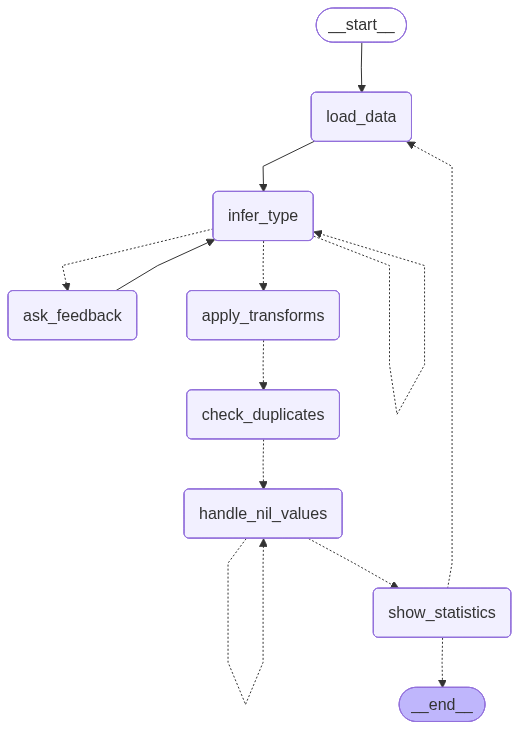

In [22]:
# Visualize the graph (optional)
try:
    from IPython.display import Image, display
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph visualization: {e}")
    print("\nGraph structure:")
    print(agent.get_graph().draw_mermaid())

## Run the Agent

Execute the agent with the configured file paths. The agent will process each file sequentially, using **LangGraph's streaming mode** with automatic interrupt handling. You'll be prompted for feedback on each column without needing to re-run the cell.

In [23]:
import uuid

# Create a unique thread ID for this session
thread_id = str(uuid.uuid4())
config = {'configurable': {'thread_id': thread_id}}

print(f"🚀 Starting agent with thread_id: {thread_id}")
print(f"📁 Files to analyze: {len(FILE_PATHS)}")
for i, fp in enumerate(FILE_PATHS):
    print(f"   {i+1}. {fp}")
print("="*70)

# Initial state for multi-file processing
current_input = {
    'files_to_process': FILE_PATHS,
    'current_file_index': 0,
    'file_states': {},
    'processing_log': [],
    'status': 'loading',
    '_show_samples_count': 5
}

# Main streaming loop using LangGraph's astream pattern
# Jupyter supports top-level await, so we can use async directly
print("\n📊 Processing...\n")

while True:
    interrupted = False
    current_node = None
    
    # Stream graph execution with updates mode
    # Note: astream returns (chunk,) when stream_mode is a single item
    async for chunk in agent.astream(
        current_input,
        stream_mode='updates',
        config=config
    ):
        # Check for interrupts
        if '__interrupt__' in chunk:
            interrupted = True
            # The interrupt info is displayed by the ask_user_feedback node
            break
        else:
            # Track node transitions
            if chunk:
                current_node = list(chunk.keys())[0]
    
    # If no interrupt occurred, check if graph reached END node
    if not interrupted:
        state = agent.get_state(config)
        # When graph reaches END, state.next is an empty tuple
        if not state.next:
            print("\n" + "="*70)
            print("✅ All files and columns have been processed!")
            print("Run the next cell to see the final results.")
            break
        else:
            # Graph paused for another reason (shouldn't happen in our flow)
            print(f"⚠️ Graph paused unexpectedly. Next nodes: {state.next}")
            break
    
    # Get user input at the interrupt point
    print("\n" + "-"*50)
    user_input = input("Your response: ")
    
    # Allow user to quit early
    if user_input.lower() in ['quit', 'exit', 'q']:
        print("\n⚠️ Agent stopped by user.")
        break
    
    # Resume graph with Command(resume=...) as the new input
    current_input = Command(resume=user_input)

🚀 Starting agent with thread_id: 3bb896fa-d4ef-4786-a92a-c8c989d5e73f
📁 Files to analyze: 1
   1. ../Airbnb/Barcelona/listings.csv

📊 Processing...


📂 FILE 1/1: ../Airbnb/Barcelona/listings.csv
✅ Loaded 19410 rows × 18 columns

🔍 [File 1] Analyzing column 1/18: 'id'
   📊 Rule-based inference: identifier (confidence: 90.0%)
   🤖 Consulting LLM for additional analysis...
   ✓ LLM agrees: identifier
   ✅ High confidence 95.0% >= 80% - auto-approving 'identifier'

🔍 [File 1] Analyzing column 2/18: 'name'
   📊 Rule-based inference: text (confidence: 60.0%)
   🤖 Consulting LLM for additional analysis...
   ✓ LLM agrees: text
   ✅ High confidence 95.0% >= 80% - auto-approving 'text'

🔍 [File 1] Analyzing column 3/18: 'host_id'
   📊 Rule-based inference: integer (confidence: 100.0%)
   🤖 Consulting LLM for additional analysis...
   ⚠️  LLM disagrees: identifier (LLM confidence: 95.0%)
      Rule-based: integer (confidence: 100.0%)
      LLM reason: The column name 'host_id' strongly suggests 

Your response:  id



╔══════════════════════════════════════════════════════════════════╗
║  FILE 1/1: listings.csv
║  COLUMN 3 of 18: host_id
╠══════════════════════════════════════════════════════════════════╣
║  Inferred Type: INTEGER
║  Confidence: 50.0%
╠══════════════════════════════════════════════════════════════════╣
║  Reasoning:
║  ⚠️ Disagreement detected:

Rule-based: integer - 100.0% are valid integers. Range: 3073 to 718612621.

LLM suggests: identifier - The column name 'host_id' strongly suggests this is an identifier field, specifically for hosts (likely in a system like Airbnb or similar hosting platform). While the values are numeric integers, the semantic meaning indicates these are unique identifiers rather than quantities to be calculated. The '_id' suffix is a clear naming convention for identifier columns.
╠══════════════════════════════════════════════════════════════════╣
║  Sample Values (5 shown):
║  ['71615', '90417', '135703', '73163', '73163']
╠═════════════════════════════

Your response:  categorical



╔══════════════════════════════════════════════════════════════════╗
║  FILE 1/1: listings.csv
║  COLUMN 6 of 18: neighbourhood
╠══════════════════════════════════════════════════════════════════╣
║  Inferred Type: TEXT
║  Confidence: 50.0%
╠══════════════════════════════════════════════════════════════════╣
║  Reasoning:
║  ⚠️ Disagreement detected:

Rule-based: text - No specific pattern. 71 unique values, avg length: 19.0 chars.

LLM suggests: categorical - The column name "neighbourhood" strongly suggests a categorical variable representing geographic districts or areas. The sample values show Spanish/Catalan neighborhood names like 'la Sagrada Família' and 'el Barri Gòtic', which are specific named locations. With 71 unique values mentioned in the rule-based analysis, this represents a finite set of neighborhood categories rather than free-form text. Neighborhoods are inherently categorical - they represent distinct, named geographic areas that can be enumerated and used for grou

...


🔍 DATA CLEANING: Checking for Nil/Missing Values

📊 Column with missing values: reviews_per_month
   Missing: 3486 values (22.82%)
   Type: Numeric

╔══════════════════════════════════════════════════════════════════╗
║  MISSING VALUES IN: reviews_per_month
╠══════════════════════════════════════════════════════════════════╣
║  Missing count: 3486 (22.82%)
║  Column type: Numeric
╠══════════════════════════════════════════════════════════════════╣
║  OPTIONS:
║  • Fill with median
║  • Fill with 0
║  • Drop rows with missing
║  • Leave empty
╚══════════════════════════════════════════════════════════════════╝


🤖 Interpreting your response: 'fill with 0'...
   Action: fill_zero
   Reasoning: The user explicitly said "fill with 0" which directly corresponds to the 'fill_zero' action for numeric columns. This makes sense for a reviews_per_month column where 0 would indicate no reviews in that time period.

📝 Filled 3486 nil values in 'reviews_per_month' with 0

🔍 DATA CLEANING: Checking

Your response:  leave empty



🔍 DATA CLEANING: Checking for Nil/Missing Values

📊 Column with missing values: license
   Missing: 3534 values (23.13%)
   Type: Text/Categorical

╔══════════════════════════════════════════════════════════════════╗
║  MISSING VALUES IN: license
╠══════════════════════════════════════════════════════════════════╣
║  Missing count: 3534 (23.13%)
║  Column type: Text/Categorical
╠══════════════════════════════════════════════════════════════════╣
║  OPTIONS:
║  • Fill with 'Unknown'
║  • Fill with most common
║  • Drop rows
║  • Leave empty
╚══════════════════════════════════════════════════════════════════╝


🤖 Interpreting your response: 'leave empty'...
   Action: leave_empty
   Reasoning: The user explicitly said "leave empty" which directly corresponds to the 'leave_empty' option, meaning they want to keep the missing values as-is without any modification.

📝 Left 3534 nil values in 'license' unchanged

🔍 DATA CLEANING: Checking for Nil/Missing Values
✅ All columns with nil values

Your response:  drop license column



📊 DATA EXPLORATION: Column Statistics

Column                    Type         Non-Null   Unique   Min          Max          Median       Outliers  
--------------------------------------------------------------------------------------------------------------
id                        str          15276      15276    N/A          N/A          N/A          N/A       
name                      str          15276      14607    N/A          N/A          N/A          N/A       
host_id                   str          15276      4538     N/A          N/A          N/A          N/A       
host_name                 str          15276      2458     N/A          N/A          N/A          N/A       
neighbourhood_group       category     15276      10       N/A          N/A          N/A          N/A       
neighbourhood             category     15276      71       N/A          N/A          N/A          N/A       
latitude                  float64      15276      9274     41.35        41.46        4

## View Results

After all files and columns are processed, view the final results for each file.

In [24]:
# Get final state
final_state = agent.get_state(config).values

print("="*70)
print("📊 FINAL RESULTS")
print("="*70)

print(f"\nOverall Status: {final_state.get('status', 'unknown')}")
print(f"Files processed: {len(final_state.get('file_states', {}))}")

# Show results for each file
for file_path, file_state in final_state.get('file_states', {}).items():
    print("\n" + "="*70)
    print(f"📁 FILE: {Path(file_path).name}")
    print(f"   Status: {file_state.get('status', 'unknown')}")
    print(f"   Columns: {len(file_state.get('column_info', {}))}")
    print("-"*70)
    
    for col_name, col_info in file_state.get('column_info', {}).items():
        approved = "✓" if col_info.get('user_approved') else "✗"
        correction = col_info.get('user_correction', '')
        final_type = correction if correction and correction != 'skip' else col_info.get('inferred_type', 'unknown')
        transformed = "🔧" if col_info.get('transformation_applied') else ""
        
        print(f"     {approved} {col_name}: {final_type} {transformed}")

print("\n" + "="*70)
print("PROCESSING LOG")
print("="*70)
for log_entry in final_state.get('processing_log', []):
    print(f"  • {log_entry}")

📊 FINAL RESULTS

Overall Status: complete
Files processed: 1

📁 FILE: listings.csv
   Status: transformed
   Columns: 18
----------------------------------------------------------------------
     ✓ id: identifier 🔧
     ✓ name: text 🔧
     ✗ host_id: identifier 🔧
     ✓ host_name: text 🔧
     ✓ neighbourhood_group: categorical 🔧
     ✗ neighbourhood: categorical 🔧
     ✓ latitude: float 🔧
     ✓ longitude: float 🔧
     ✓ room_type: categorical 🔧
     ✓ price: integer 🔧
     ✓ minimum_nights: integer 🔧
     ✓ number_of_reviews: integer 🔧
     ✓ last_review: datetime 🔧
     ✓ reviews_per_month: float 🔧
     ✓ calculated_host_listings_count: integer 🔧
     ✓ availability_365: integer 🔧
     ✓ number_of_reviews_ltm: integer 🔧
     ✗ license: identifier 🔧

PROCESSING LOG
  • [File 1] Loaded 19410 rows × 18 columns from ../Airbnb/Barcelona/listings.csv
  • [File 1] Inferred type for 'id': identifier (confidence: 95.0%) - AUTO-APPROVED
  • [File 1] Inferred type for 'name': text (confidence:

In [25]:
# Get transformed DataFrames for all files
final_state = agent.get_state(config).values

file_states = final_state.get('file_states', {})

if file_states:
    for file_path, file_state in file_states.items():
        print("="*70)
        print(f"📁 {Path(file_path).name}")
        print("="*70)
        
        if file_state.get('working_df') is not None:
            df_final = file_state['working_df']
            
            print("\n📋 DataFrame Info:")
            print(df_final.info())
            
            print("\n📊 First 5 rows:")
            display(df_final.head())
            
            # Also show original for comparison if needed
            if file_state.get('original_df') is not None:
                print("\n📋 Original DataFrame shape:", file_state['original_df'].shape)
        else:
            print("No data available for this file.")
        print()
else:
    print("No data available. Make sure the agent has completed.")

📁 listings.csv

📋 DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 15276 entries, 0 to 15275
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              15276 non-null  str           
 1   name                            15276 non-null  str           
 2   host_id                         15276 non-null  str           
 3   host_name                       15276 non-null  str           
 4   neighbourhood_group             15276 non-null  category      
 5   neighbourhood                   15276 non-null  category      
 6   latitude                        15276 non-null  float64       
 7   longitude                       15276 non-null  float64       
 8   room_type                       15276 non-null  category      
 9   price                           15276 non-null  Int64         
 10  minimum_nights                  15276 non-null 

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,18674,Huge flat for 8 people close to Sagrada Familia,71615,Mireia,Eixample,la Sagrada Família,41.405560,2.17262,Entire home/apt,210,1,51,2025-07-31,0.34,26,80,7
1,23197,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",90417,Etain (Marnie),Sant Martí,el Besòs i el Maresme,41.412432,2.21975,Entire home/apt,285,3,91,2025-09-08,0.52,1,289,12
2,32711,Sagrada Familia area - Còrsega 1,135703,Nick,Gràcia,el Camp d'en Grassot i Gràcia Nova,41.405660,2.17015,Entire home/apt,170,1,152,2025-08-08,0.88,2,64,23
3,34241,Stylish Top Floor Apartment - Ramblas Plaza Real,73163,Andres,Ciutat Vella,el Barri Gòtic,41.380620,2.17517,Entire home/apt,110,31,25,2024-11-05,0.14,3,333,5
4,34981,VIDRE HOME PLAZA REAL on LAS RAMBLAS,73163,Andres,Ciutat Vella,el Barri Gòtic,41.379780,2.17623,Entire home/apt,333,5,271,2025-08-19,1.49,3,335,23



📋 Original DataFrame shape: (19410, 18)



---
## Next Steps

This agent provides a foundation for data analysis. Possible extensions:

1. **Data Cleaning**: Add nodes for handling missing values, outliers, etc.
2. **Feature Engineering**: Create new columns based on existing ones
3. **Analysis**: Compute statistics, correlations, and summaries
4. **Visualization**: Generate plots and charts
5. **Export**: Save the cleaned data to various formats